**Install:** `pip install -U langchain langchain-openai langgraph`

# 🎯 9. Single-Agent Architectures

We've learned all the components: tools, memory, planning, ReAct. Now we assemble them into **complete, modular agent systems**.

In this notebook:

1. **Modular agent design** — separating concerns
2. **Worker-Evaluator loop** — self-improving agents
3. **Human-in-the-loop** — interrupt, review, resume
4. **Building a complete research agent**

In [1]:
import os, json
from pathlib import Path
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import MessagesState
from langgraph.checkpoint.memory import MemorySaver
from typing_extensions import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

# Φορτώνουμε τα API keys από το .env (βρίσκεται στο root του project)
_env_path = Path(".env")
load_dotenv(dotenv_path=_env_path, override=False)

# Αν δεν βρεθεί το key (πχ σε Colab), ζητάμε manually
# if not os.environ.get("OPENAI_API_KEY"):
#     import getpass
#     os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

LLM_MODEL = "gpt-4o-mini"



llm = ChatOpenAI(model=LLM_MODEL, temperature=0)
print(f'Model: {LLM_MODEL}')

c:\Users\user\Desktop\ai-agents-course-me\venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


Model: gpt-4o-mini


In [2]:
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))

LangSmith tracing: true
LangSmith project: my-ai-agents-demo


## 9.1 Modular Agent Design

A well-designed agent separates concerns into distinct modules:

<img src="images/mod-agent-design.png" width="50%" style="border-radius:10px;margin:12px 0;"/>

### 9.1.1 Hardcoded Agent

In [3]:
from langchain_core.messages import ToolMessage
import math


class AgentSystem:
    """A modular agent system with tools, memory, and planning."""

    def __init__(self, name: str, system_prompt: str, llm_model=None):
        self.name = name
        self.system_prompt = system_prompt
        self.llm = llm_model or ChatOpenAI(model=LLM_MODEL, temperature=0)
        self.tools = []
        self.memory = []  # conversation history
        self.facts = {}  # long-term memory

    def add_tool(self, tool_fn):
        self.tools.append(tool_fn)

    def remember(self, key: str, value: str):
        self.facts[key] = value

    def get_context(self) -> str:
        if not self.facts:
            return ''
        facts_str = '\n'.join([f'- {k}: {v}' for k, v in self.facts.items()])
        return f'\nKnown facts:\n{facts_str}'

    def run(self, query: str) -> str:
        full_prompt = self.system_prompt + self.get_context()
        self.memory.append(HumanMessage(content=query))

        llm_with_tools = self.llm.bind_tools(self.tools) if self.tools else self.llm

        messages = [SystemMessage(content=full_prompt)] + self.memory
        response = llm_with_tools.invoke(messages)

        # Handle tool calls
        if hasattr(response, 'tool_calls') and response.tool_calls:
            self.memory.append(response)
            for tc in response.tool_calls:
                tool_fn = next((t for t in self.tools if t.name == tc['name']), None)
                if tool_fn:
                    result = tool_fn.invoke(tc['args'])
                    
                    self.memory.append(ToolMessage(content=str(result), tool_call_id=tc['id']))
            # Get final response
            response = self.llm.invoke([SystemMessage(content=full_prompt)] + self.memory)

        self.memory.append(response)
        return response.content

# Create and test the agent
@tool
def calculator(expression: str) -> str:
    """Evaluate a NUMERIC mathematical expression only.
    
    Valid: 'sqrt(625) * 3', '2 ** 10', 'pow(2, 8)'
    Invalid: names, words, or anything non-numeric.
    
    Use ONLY for arithmetic. For factual/memory questions do NOT use this tool.
    """
    try:
        result = eval(
            expression,
            {'__builtins__': {}},
            {'sqrt': math.sqrt, 'pow': pow, 'abs': abs, 'round': round, 'pi': math.pi}
        )
        return str(result)
    except Exception as e:
        return f"Calculator error: '{expression}' is not a valid math expression. ({e})"

agent = AgentSystem(
    name='Research Assistant',
    system_prompt='You are a helpful research assistant. Be concise and accurate.'
)
agent.add_tool(calculator)
agent.remember('user_name', 'Alex')
agent.remember('preference', 'prefers concise answers')

print(agent.run('What is my name? Also calculate sqrt(625) * 3? NO LaTeX'))

Your name is Alex. The result of sqrt(625) * 3 is 75.


### 9.1.2. create_agent

In [4]:
# Όλο το AgentSystem class (memory, facts, tool binding, run loop)
# γίνεται μία γραμμή. Persistence: checkpointer για conversation,
# Tools: λίστα από @tool, system prompt: prompt argument.
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langchain.agents import create_agent

@tool
def get_weather(city: str) -> str:
    """Get current weather for a city."""
    weather = {'london': 'Cloudy 12C', 'tokyo': 'Sunny 24C', 'paris': 'Cloudy 16C'}
    return weather.get(city.lower(), f'No data for {city}')

@tool
def remember_fact(fact: str) -> str:
    """Save a fact to long-term memory (returns confirmation)."""
    return f'Saved: {fact}'

agent = create_agent(
    model=llm,
    tools=[get_weather, remember_fact],
    system_prompt='You are a personal assistant who can check weather and remember facts.',
    checkpointer=MemorySaver(),
)

config = {'configurable': {'thread_id': 'agent-9-1'}}
r1 = agent.invoke({'messages': [HumanMessage(content='What is the weather in Tokyo?')]}, config=config)
print(r1['messages'][-1].content)


The weather in Tokyo is sunny with a temperature of 24°C.


## 9.2 Worker-Evaluator Loop

A powerful pattern where one agent **generates** and another **evaluates**:

<img src="images/worker-evaluator-loop.png" width="50%" style="border-radius:10px;margin:12px 0;"/>

In [5]:
class EvalResult(BaseModel):
    score: int = Field(ge=1, le=10, description='Quality score 1-10')
    is_acceptable: bool = Field(description='Whether the output meets quality standards')
    feedback: str = Field(description='Specific improvement suggestions')

evaluator_llm = llm.with_structured_output(EvalResult)

def worker_evaluator_loop(task: str, max_rounds: int = 3) -> str:
    """Generate output, evaluate it, improve iteratively."""
    output = ''

    for round_num in range(1, max_rounds + 1):
        print(f'\n--- Round {round_num} ---')

        # WORKER: Generate or improve
        if round_num == 1:
            worker_prompt = f'Complete this task: {task}'
        else:
            worker_prompt = f'Improve this based on feedback:\n\nOutput:\n{output}\n\nFeedback:\n{feedback}'

        response = llm.invoke([HumanMessage(content=worker_prompt)])
        output = response.content
        print(f'Worker output: {output[:150]}...')

        # EVALUATOR: Score the output
        eval_result = evaluator_llm.invoke(
            f'Evaluate this output for the task "{task}":\n\n{output}'
        )
        print(f'Score: {eval_result.score}/10 | Acceptable: {eval_result.is_acceptable}')

        if eval_result.is_acceptable:
            print(f'\n✅ Approved after {round_num} round(s)!')
            return output

        feedback = eval_result.feedback
        print(f'Feedback: {feedback}')

    return output

result = worker_evaluator_loop(
    'Write a clear, technical definition of the ReAct agent pattern in exactly 3 sentences.'
)


--- Round 1 ---
Worker output: The ReAct agent pattern is a framework for building intelligent agents that can dynamically respond to their environment by combining reasoning and ac...
Score: 7/10 | Acceptable: True

✅ Approved after 1 round(s)!


In [6]:
result_2 = worker_evaluator_loop(
    """
    Write a clear, technical definition of the ReAct agent pattern.

    Evaluation rule:
    - The output is acceptable only if all requirements below are satisfied.
    - If one requirement is violated, mark is_acceptable as false.
    - If the output is unacceptable, feedback must clearly say what to change and include enough information to preserve the original task constraints.

    Requirements:
    - Use exactly 3 sentences.
    - Sentence 1 must start with ReAct is and define it as a control pattern.
    - Sentence 2 must include the exact phrase Reason, Act, and Observe exactly once.
    - Sentence 2 must explain how the three steps interact.
    - Sentence 3 must explain why ReAct improves reliability, but Sentence 3 must not use the word reliability.
    - Sentence 3 must include the phrase external feedback.
    - Do not use bullet points.
    """
)


--- Round 1 ---
Worker output: ReAct is a control pattern that facilitates decision-making in dynamic environments by integrating reasoning, action, and observation. The steps Reaso...
Score: 8/10 | Acceptable: False
Feedback: The output does not meet the requirement for sentence structure. Sentence 1 correctly starts with 'ReAct is' and defines it as a control pattern. However, Sentence 2 does not include the exact phrase 'Reason, Act, and Observe' as required; it uses 'reasoning, action, and observation' instead. Additionally, Sentence 3 does not explain why ReAct improves reliability without using the word 'reliability' as required. To improve, ensure that Sentence 2 uses the exact phrase and that Sentence 3 avoids the word 'reliability' while still explaining the improvement.

--- Round 2 ---
Worker output: ReAct is a control pattern that facilitates decision-making in dynamic environments by integrating reasoning, action, and observation. The steps Reaso...
Score: 8/10 | Acceptab

## 9.3 Human-in-the-Loop Patterns

Some agent actions need human approval before execution. LangGraph supports this with **interrupts**:

| Pattern | Use Case |
|---------|----------|
| **Approve/Reject** | Sensitive actions (payments, emails) |
| **Edit & Continue** | Modify agent's plan before execution |
| **Provide Input** | Agent asks for missing information |

This is implemented in LangGraph using `interrupt_before` on specific nodes.

<img src="images/hitl-pattern.png" width="80%" style="border-radius:10px;margin:12px 0;"/>

1. Send an email to the team about the product launch
2. yes

In [9]:
from IPython.display import display, Markdown

# Simulated Human-in-the-Loop pattern
class HumanApprovalState(TypedDict):
    messages: Annotated[list, operator.add]
    proposed_action: str
    approved: bool
    result: str

def propose_action(state: HumanApprovalState) -> dict:
    last_msg = state['messages'][-1]
    content = last_msg.content if hasattr(last_msg, 'content') else str(last_msg)
    response = llm.invoke([
        SystemMessage(content='Propose an action for this request. State what you would do.'),
        HumanMessage(content=content)
    ])
    return {'proposed_action': response.content}

def simulate_human_review(state: HumanApprovalState) -> dict:
    """In production, this would pause and wait for real human input."""
    action = state['proposed_action']
    display(Markdown(f'  🔍 Human reviewing: {action}'))

    decision = input('Approve this action? (yes/no): ').strip().lower()
    return {'approved': decision in ['yes', 'y', 'approve', 'approved']}

def execute_action(state: HumanApprovalState) -> dict:
    if state['approved']:
        return {
            'result': f'Action executed: {state["proposed_action"]}',
            'messages': [AIMessage(content='Action completed successfully.')]
        }

    return {
        'result': 'Action rejected by human reviewer.',
        'messages': [AIMessage(content='Action was rejected.')]
    }

# Build graph
hitl_graph = StateGraph(HumanApprovalState)
hitl_graph.add_node('propose', propose_action)
hitl_graph.add_node('review', simulate_human_review)
hitl_graph.add_node('execute', execute_action)

hitl_graph.add_edge(START, 'propose')
hitl_graph.add_edge('propose', 'review')
hitl_graph.add_edge('review', 'execute')
hitl_graph.add_edge('execute', END)

hitl_app = hitl_graph.compile()

user_request = input('What do you want the agent to do? ')

result = hitl_app.invoke({
    'messages': [HumanMessage(content=user_request)],
    'proposed_action': '',
    'approved': False,
    'result': ''
})



display(Markdown(f'Result: {result["result"]}'))

  🔍 Human reviewing: To provide information about summer in Athens, I would compile a guide that includes key aspects such as:

1. **Weather**: Describe the typical weather conditions in Athens during summer, including average temperatures, humidity levels, and any notable weather patterns.

2. **Activities**: Suggest popular summer activities and attractions, such as visiting historical sites like the Acropolis, enjoying outdoor cafes, and exploring local markets.

3. **Events**: Highlight any summer festivals, concerts, or cultural events that take place in Athens during this season.

4. **Travel Tips**: Offer practical advice for visitors, including the best times to visit attractions to avoid crowds, recommendations for local cuisine, and tips for staying cool in the heat.

5. **Transportation**: Provide information on how to get around the city during the summer, including public transport options and any seasonal services.

This guide would be useful for anyone planning to visit Athens during the summer months.

Result: Action rejected by human reviewer.

### 9.3.2. Add some user input

In [10]:
# ============================================================
# Human-in-the-Loop Agent with Real User Input
# LangGraph + input()
# ============================================================

from typing import Optional, Literal
from typing_extensions import TypedDict, Annotated
import operator

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END


# ============================================================
# State
# ============================================================

class HumanApprovalState(TypedDict):
    messages: Annotated[list, operator.add]
    proposed_action: str
    approved: Optional[bool]
    human_feedback: Optional[str]
    result: str


# ============================================================
# Node 1: Agent proposes an action
# ============================================================

def propose_action(state: HumanApprovalState) -> dict:
    last_message = state["messages"][-1]
    user_request = last_message.content if hasattr(last_message, "content") else str(last_message)

    response = llm.invoke([
        SystemMessage(content="""
You are an AI assistant inside a human-in-the-loop workflow.

Your job is to propose a concrete action based on the user's request.

Important rules:
- Do not execute anything.
- Do not claim that the action has already been completed.
- Only describe the action that should be reviewed by a human.
- Be clear and specific.
"""),
        HumanMessage(content=user_request)
    ])

    return {
        "proposed_action": response.content,
        "messages": [
            AIMessage(content=f"Proposed action:\n\n{response.content}")
        ]
    }


# ============================================================
# Node 2: Human review with real user input
# ============================================================

def human_review(state: HumanApprovalState) -> dict:
    print("\n" + "=" * 70)
    print("HUMAN REVIEW REQUIRED")
    print("=" * 70)

    print("\nThe agent proposes the following action:\n")
    print(state["proposed_action"])

    print("\nAvailable options:")
    print("1. yes  -> approve the action")
    print("2. no   -> reject the action")
    print("3. edit -> modify the action before execution")

    while True:
        decision = input("\nApprove this action? Type yes / no / edit: ").strip().lower()

        if decision in ["yes", "y"]:
            feedback = input("Optional feedback for approval: ").strip()

            return {
                "approved": True,
                "human_feedback": feedback or "Approved by the human user."
            }

        elif decision in ["no", "n"]:
            feedback = input("Why do you reject this action? ").strip()

            return {
                "approved": False,
                "human_feedback": feedback or "Rejected by the human user."
            }

        elif decision == "edit":
            print("\nCurrent proposed action:")
            print(state["proposed_action"])

            edited_action = input("\nWrite the corrected action: ").strip()

            while not edited_action:
                print("The edited action cannot be empty.")
                edited_action = input("Write the corrected action: ").strip()

            feedback = input("Optional feedback for this edit: ").strip()

            return {
                "approved": True,
                "proposed_action": edited_action,
                "human_feedback": feedback or "The action was edited and approved by the human user."
            }

        else:
            print("Invalid input. Please type yes, no, or edit.")


# ============================================================
# Router after human review
# ============================================================

def route_after_review(state: HumanApprovalState) -> Literal["execute_action", "reject_action"]:
    if state["approved"]:
        return "execute_action"

    return "reject_action"


# ============================================================
# Node 3A: Execute approved action
# ============================================================

def execute_action(state: HumanApprovalState) -> dict:
    action = state["proposed_action"]
    feedback = state.get("human_feedback") or "No feedback provided."

    print("\n" + "=" * 70)
    print("EXECUTING APPROVED ACTION")
    print("=" * 70)

    print("\nApproved action:")
    print(action)

    print("\nHuman feedback:")
    print(feedback)

    result_message = f"""
The action was approved by the human user and is now executed.

Approved action:
{action}

Human feedback:
{feedback}
""".strip()

    return {
        "result": result_message,
        "messages": [
            AIMessage(content=result_message)
        ]
    }


# ============================================================
# Node 3B: Reject action
# ============================================================

def reject_action(state: HumanApprovalState) -> dict:
    feedback = state.get("human_feedback") or "No feedback provided."

    print("\n" + "=" * 70)
    print("ACTION REJECTED")
    print("=" * 70)

    print("\nHuman feedback:")
    print(feedback)

    result_message = f"""
The proposed action was rejected by the human user.

Human feedback:
{feedback}
""".strip()

    return {
        "result": result_message,
        "messages": [
            AIMessage(content=result_message)
        ]
    }


# ============================================================
# Build the graph
# ============================================================

hitl_graph = StateGraph(HumanApprovalState)

hitl_graph.add_node("propose_action", propose_action)
hitl_graph.add_node("human_review", human_review)
hitl_graph.add_node("execute_action", execute_action)
hitl_graph.add_node("reject_action", reject_action)

hitl_graph.add_edge(START, "propose_action")
hitl_graph.add_edge("propose_action", "human_review")

hitl_graph.add_conditional_edges(
    "human_review",
    route_after_review,
    {
        "execute_action": "execute_action",
        "reject_action": "reject_action"
    }
)

hitl_graph.add_edge("execute_action", END)
hitl_graph.add_edge("reject_action", END)

hitl_app = hitl_graph.compile()


# ============================================================
# Run the HITL agent
# ============================================================

user_request = input("Give your request to the agent: ").strip()

while not user_request:
    print("The request cannot be empty.")
    user_request = input("Give your request to the agent: ").strip()

initial_state: HumanApprovalState = {
    "messages": [
        HumanMessage(content=user_request)
    ],
    "proposed_action": "",
    "approved": None,
    "human_feedback": None,
    "result": ""
}

final_result = hitl_app.invoke(initial_state)


# ============================================================
# Final result
# ============================================================

print("\n" + "=" * 70)
print("FINAL RESULT")
print("=" * 70)

print(final_result["result"])


HUMAN REVIEW REQUIRED

The agent proposes the following action:

Please provide more context or specify what you would like to know or do regarding "Summer in Athens." For example, are you looking for travel tips, activities, events, or something else?

Available options:
1. yes  -> approve the action
2. no   -> reject the action
3. edit -> modify the action before execution
Invalid input. Please type yes, no, or edit.

EXECUTING APPROVED ACTION

Approved action:
Please provide more context or specify what you would like to know or do regarding "Summer in Athens." For example, are you looking for travel tips, activities, events, or something else?

Human feedback:
Approved by the human user.

FINAL RESULT
The action was approved by the human user and is now executed.

Approved action:
Please provide more context or specify what you would like to know or do regarding "Summer in Athens." For example, are you looking for travel tips, activities, events, or something else?

Human feedback

### 9.3.3. import `tavily` and make some real search

`pip install langchain-tavily`

In [17]:
# ============================================================
# Human-in-the-Loop Agent with Real Web Search Tool
# LangGraph + input() + TavilySearch
# ============================================================

# If needed, run once:
# !pip install -U langgraph langchain langchain-openai langchain-tavily

from typing import Optional, Literal, Any
from typing_extensions import TypedDict, Annotated
import operator
import os
import getpass
import json

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch

from langgraph.graph import StateGraph, START, END
from IPython.display import display, Markdown

_env_path = Path(".env")
load_dotenv(dotenv_path=_env_path, override=True)

# ============================================================
# API keys
# ============================================================

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

if not os.environ.get("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Tavily API key: ")


# ============================================================
# LLM + Web Search Tool
# ============================================================

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

web_search_tool = TavilySearch(
    max_results=5,
    topic="general",
    include_answer=True,
    include_raw_content=False,
    include_images=False
)


# ============================================================
# State
# ============================================================

class HumanApprovalState(TypedDict):
    messages: Annotated[list, operator.add]
    user_request: str
    proposed_action: str
    search_query: str
    approved: Optional[bool]
    human_feedback: Optional[str]
    search_results: Optional[Any]
    result: str


# ============================================================
# Utility: safely parse JSON from LLM
# ============================================================

def safe_json_parse(text: str) -> dict:
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {}


# ============================================================
# Node 1: Agent proposes a real web search action
# ============================================================

def propose_action(state: HumanApprovalState) -> dict:
    user_request = state["user_request"]

    response = llm.invoke([
        SystemMessage(content="""
You are an AI assistant inside a human-in-the-loop workflow.

The user may ask for information that requires current web search.

Your job:
1. Decide a good web search query.
2. Propose a clear action for the human to approve.
3. Do not perform the search yet.

Return ONLY valid JSON with this schema:

{
  "search_query": "the exact web search query",
  "proposed_action": "clear explanation of what will be searched and why"
}

Important rules:
- Do not execute the search.
- Do not claim that the information has already been found.
- Make the search query concise and precise.
"""),
        HumanMessage(content=user_request)
    ])

    parsed = safe_json_parse(response.content)

    search_query = parsed.get("search_query", user_request)
    proposed_action = parsed.get(
        "proposed_action",
        f"Search the web for: {search_query}"
    )

    return {
        "search_query": search_query,
        "proposed_action": proposed_action,
        "messages": [
            AIMessage(content=f"Proposed web search:\n\n{proposed_action}\n\nSearch query:\n{search_query}")
        ]
    }


# ============================================================
# Node 2: Human review with real user input
# ============================================================

def human_review(state: HumanApprovalState) -> dict:
    print("\n" + "=" * 70)
    print("HUMAN REVIEW REQUIRED")
    print("=" * 70)

    print("\nThe agent proposes this web-search action:\n")
    print(state["proposed_action"])

    print("\nSearch query:")
    print(state["search_query"])

    print("\nAvailable options:")
    print("1. yes  -> approve and run the web search")
    print("2. no   -> reject the web search")
    print("3. edit -> change the search query before running it")

    while True:
        decision = input("\nApprove this search? Type yes / no / edit: ").strip().lower()

        if decision in ["yes", "y"]:
            feedback = input("Optional feedback for approval: ").strip()

            return {
                "approved": True,
                "human_feedback": feedback or "Approved by the human user."
            }

        elif decision in ["no", "n"]:
            feedback = input("Why do you reject this search? ").strip()

            return {
                "approved": False,
                "human_feedback": feedback or "Rejected by the human user."
            }

        elif decision == "edit":
            print("\nCurrent search query:")
            print(state["search_query"])

            edited_query = input("\nWrite the corrected search query: ").strip()

            while not edited_query:
                print("The search query cannot be empty.")
                edited_query = input("Write the corrected search query: ").strip()

            feedback = input("Optional feedback for this edit: ").strip()

            return {
                "approved": True,
                "search_query": edited_query,
                "proposed_action": f"Search the web for: {edited_query}",
                "human_feedback": feedback or "The search query was edited and approved by the human user."
            }

        else:
            print("Invalid input. Please type yes, no, or edit.")


# ============================================================
# Router after human review
# ============================================================

def route_after_review(state: HumanApprovalState) -> Literal["execute_web_search", "reject_action"]:
    if state["approved"]:
        return "execute_web_search"

    return "reject_action"


# ============================================================
# Node 3A: Execute real web search
# ============================================================

def execute_web_search(state: HumanApprovalState) -> dict:
    search_query = state["search_query"]
    feedback = state.get("human_feedback") or "No feedback provided."

    print("\n" + "=" * 70)
    print("EXECUTING REAL WEB SEARCH")
    print("=" * 70)

    print("\nApproved search query:")
    print(search_query)

    print("\nHuman feedback:")
    print(feedback)

    raw_results = web_search_tool.invoke({
        "query": search_query
    })

    return {
        "search_results": raw_results,
        "messages": [
            AIMessage(content=f"Web search completed for query:\n\n{search_query}")
        ]
    }


# ============================================================
# Node 3B: Summarize search results
# ============================================================

def summarize_search_results(state: HumanApprovalState) -> dict:
    user_request = state["user_request"]
    search_query = state["search_query"]
    raw_results = state["search_results"]

    response = llm.invoke([
        SystemMessage(content="""
You are an assistant that summarizes web search results.

Your job:
- Answer the user's original request using the provided search results.
- Be concise but useful.
- Mention the most relevant source URLs when available.
- If the search results are insufficient, say so clearly.
"""),
        HumanMessage(content=f"""
Original user request:
{user_request}

Approved search query:
{search_query}

Raw web search results:
{raw_results}
""")
    ])

    result_message = response.content

    print("\n" + "=" * 70)
    print("WEB SEARCH ANSWER")
    print("=" * 70)
    print(result_message)

    return {
        "result": result_message,
        "messages": [
            AIMessage(content=result_message)
        ]
    }


# ============================================================
# Node 3C: Reject action
# ============================================================

def reject_action(state: HumanApprovalState) -> dict:
    feedback = state.get("human_feedback") or "No feedback provided."

    print("\n" + "=" * 70)
    print("WEB SEARCH REJECTED")
    print("=" * 70)

    print("\nHuman feedback:")
    print(feedback)

    result_message = f"""
The proposed web search was rejected by the human user.

Human feedback:
{feedback}
""".strip()

    return {
        "result": result_message,
        "messages": [
            AIMessage(content=result_message)
        ]
    }


# ============================================================
# Build the graph
# ============================================================

hitl_graph = StateGraph(HumanApprovalState)

hitl_graph.add_node("propose_action", propose_action)
hitl_graph.add_node("human_review", human_review)
hitl_graph.add_node("execute_web_search", execute_web_search)
hitl_graph.add_node("summarize_search_results", summarize_search_results)
hitl_graph.add_node("reject_action", reject_action)

hitl_graph.add_edge(START, "propose_action")
hitl_graph.add_edge("propose_action", "human_review")

hitl_graph.add_conditional_edges(
    "human_review",
    route_after_review,
    {
        "execute_web_search": "execute_web_search",
        "reject_action": "reject_action"
    }
)

hitl_graph.add_edge("execute_web_search", "summarize_search_results")
hitl_graph.add_edge("summarize_search_results", END)
hitl_graph.add_edge("reject_action", END)

hitl_app = hitl_graph.compile()

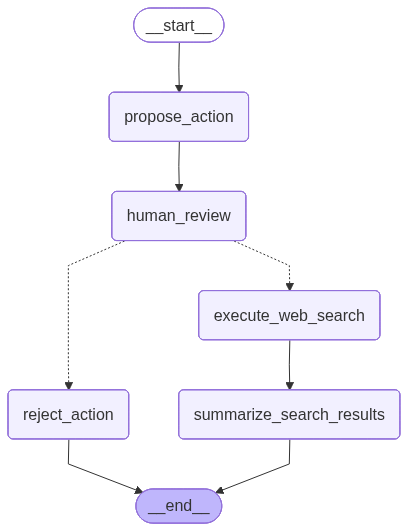

In [14]:
from IPython.display import display, Image

display(Image(hitl_app.get_graph().draw_mermaid_png()))

In [18]:

# ============================================================
# Run the HITL web-search agent
# ============================================================

user_request = input("Give your request to the agent: ").strip()

while not user_request:
    print("The request cannot be empty.")
    user_request = input("Give your request to the agent: ").strip()

initial_state: HumanApprovalState = {
    "messages": [
        HumanMessage(content=user_request)
    ],
    "user_request": user_request,
    "proposed_action": "",
    "search_query": "",
    "approved": None,
    "human_feedback": None,
    "search_results": None,
    "result": ""
}

final_result = hitl_app.invoke(initial_state)


# ============================================================
# Final result
# ============================================================

print("\n" + "=" * 70)
print("FINAL RESULT")
print("=" * 70)
display(Markdown(final_result["result"]))


HUMAN REVIEW REQUIRED

The agent proposes this web-search action:

I will search for news articles and events that took place in Athens during the year 2022 to provide you with a summary of significant happenings.

Search query:
Athens news and events 2022

Available options:
1. yes  -> approve and run the web search
2. no   -> reject the web search
3. edit -> change the search query before running it

Current search query:
Athens news and events 2022

EXECUTING REAL WEB SEARCH

Approved search query:
Athens in 1970

Human feedback:
The search query was edited and approved by the human user.

WEB SEARCH ANSWER
In the 1970s, Athens was known for being one of the most polluted cities in the world. Archival footage and photographs from that era depict daily life and urban scenes, highlighting the challenges of pollution and urbanization. 

For visual references, you can explore:
- [Athens, Greece, 1970s on Reddit](https://www.reddit.com/r/CityPorn/comments/142hz32/athens_greece_1970s)
- 

In the 1970s, Athens was known for being one of the most polluted cities in the world. Archival footage and photographs from that era depict daily life and urban scenes, highlighting the challenges of pollution and urbanization. 

For visual references, you can explore:
- [Athens, Greece, 1970s on Reddit](https://www.reddit.com/r/CityPorn/comments/142hz32/athens_greece_1970s)
- [Photo Gallery: Athens in the 1970s and '80s on Flagpole](https://flagpole.com/photo-gallery/2021/07/28/photo-gallery-athens-in-the-1970s-and-80s)
- [Archival footage of Athens in the 1970s on YouTube](https://www.youtube.com/watch?v=1RE7Yxj6xjg)
- [Wikimedia Commons category for Athens in the 1970s](https://commons.wikimedia.org/wiki/Category:Athens_in_the_1970s)

These sources provide a glimpse into the historical context and visual representation of Athens during that decade.

## 💡 Exercise 9: Build a Modular Research Agent

**Task**: Build an AgentSystem that:
1. Has tools for search, calculator, and note-taking
2. Uses the worker-evaluator loop for quality
3. Maintains memory across queries

Test with a multi-step research task.

In [ ]:
# Exercise 9: YOUR CODE HERE


## 📝 Summary

| Concept | Key Takeaway |
|---------|-------------|
| **Modular design** | Separate tool manager, memory, planner, executor |
| **Worker-Evaluator** | Generate → score → improve loop for quality |
| **Human-in-the-loop** | Interrupt for approval on sensitive actions |

### What's Next

In **Notebook 10: Multi-Agent Systems**, we move from single agents to teams of agents that communicate, delegate, and collaborate.